# 1D Periodogram Covariance — Formula Validation

## 핵심 질문

Hann taper + Gaussian AR(1) 에서:
- **Spectral leakage** 때문에 Cov(I_j, I_k) ≠ 0 for j ≠ k
- 이 coupling 이 공식 $|S_{jk}|^2 + |P_{jk}|^2$ 으로 정확히 예측되는가?

**설계**:
- N = 128 (짧은 시계열 → taper bandwidth 가 주파수 간격보다 커서 leakage visible)
- 가까운 주파수 쌍 포함 (index 차이 1~3): Cov_gauss ≠ 0 예측
- T = 2000 snapshots → Cov_emp 의 sampling noise 충분히 작게
- **True f** 로 계산하면: Cov_emp ≈ Cov_gauss(true f) 이어야 함 (공식 검증)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

# ── Setup ─────────────────────────────────────────────────────────────────────
N      = 128     # time series length
T      = 2000    # number of realizations
RHO    = 0.85    # AR(1) coefficient  (red spectrum)
SIGMA2 = 1.0     # innovation variance
SEED   = 42

# Hann taper (normalized)
h = np.hanning(N)
h /= np.sqrt(np.mean(h**2))    # ||h||^2 = N
W = fft(h)                      # W[m] = FFT(h)[m]

# Frequency selection: include NEARBY pairs to expose leakage coupling
# Taper bandwidth ~ 4 bins for N=128 Hann
FREQS = [3, 4, 5, 6, 10, 15, 20, 30, 45, 60]
K = len(FREQS)
sig_thresh = 2 / np.sqrt(T)

print(f'N={N}, T={T}, rho={RHO}')
print(f'K={K} frequencies: {FREQS}')
print(f'2/sqrt(T) = {sig_thresh:.4f}')
print(f'Taper bandwidth (approx): {4} bins')
print(f'Nearby pairs (diff<=4): {[(FREQS[i],FREQS[j]) for i in range(K) for j in range(i+1,K) if abs(FREQS[i]-FREQS[j])<=4]}')

N=128, T=2000, rho=0.85
K=10 frequencies: [3, 4, 5, 6, 10, 15, 20, 30, 45, 60]
2/sqrt(T) = 0.0447
Taper bandwidth (approx): 4 bins
Nearby pairs (diff<=4): [(3, 4), (3, 5), (3, 6), (4, 5), (4, 6), (5, 6), (6, 10)]


In [2]:
# ── True spectral density for AR(1): f(w_j) = sigma^2 / |1 - rho*e^{-2pi i j/N}|^2
j_all  = np.arange(N)
f_true = SIGMA2 / np.abs(1 - RHO * np.exp(-2j * np.pi * j_all / N))**2

# Taper-corrected expectation: E[I_j] = (1/N^2) * sum_m f[m] * |W[j-m]|^2
m_idx  = np.arange(N)
EI_tap = np.array([
    np.sum(f_true * np.abs(W[(j - m_idx) % N])**2) / N**2
    for j in FREQS
])

print('True spectral density at selected frequencies:')
print(f'{"j":>5}  {"f_true[j]":>12}  {"E[I_j](taper)": >16}')
print('-'*38)
for i, j in enumerate(FREQS):
    print(f'{j:5d}  {f_true[j]:12.4f}  {EI_tap[i]:16.4f}')

True spectral density at selected frequencies:
    j     f_true[j]     E[I_j](taper)
--------------------------------------
    3       24.4499           24.7573
    4       18.1274           18.4339
    5       13.6153           13.8432
    6       10.4492           10.6053
   10        4.4796            4.5148
   15        2.1604            2.1687
   20        1.2853            1.2881
   30        0.6427            0.6433
   45        0.3656            0.3657
   60        0.2950            0.2951


In [3]:
# ── Generate T realizations of AR(1) and compute periodogram ─────────────────
rng   = np.random.default_rng(SEED)
scale = np.sqrt(N)

J_tap = np.zeros((T, K), dtype=complex)
J_raw = np.zeros((T, K), dtype=complex)

print(f'Generating {T} AR(1) realizations ...')
for t in range(T):
    # AR(1): X_t = rho * X_{t-1} + sigma * eps_t
    eps = rng.standard_normal(N) * np.sqrt(SIGMA2)
    X   = np.zeros(N)
    X[0] = eps[0] / np.sqrt(1 - RHO**2)   # stationary init
    for s in range(1, N):
        X[s] = RHO * X[s-1] + eps[s]

    X -= X.mean()
    F_tap = fft(X * h)
    F_raw = fft(X)
    for q, j in enumerate(FREQS):
        J_tap[t, q] = F_tap[j] / scale
        J_raw[t, q] = F_raw[j] / scale

I_tap     = np.abs(J_tap)**2
I_raw     = np.abs(J_raw)**2
f_hat_tap = I_tap.mean(axis=0)
f_hat_raw = I_raw.mean(axis=0)

def emp_cov(I):
    Ic = I - I.mean(axis=0)
    return (Ic.T @ Ic) / I.shape[0]

Cov_emp_tap = emp_cov(I_tap)
Cov_emp_raw = emp_cov(I_raw)
print('Done.')

Generating 2000 AR(1) realizations ...
Done.


In [4]:
# ── Gaussian baselines (1D) ───────────────────────────────────────────────────
m = np.arange(N)

def exact_cov_gauss_1d(f_spec):
    C = np.zeros((K, K))
    for i, j in enumerate(FREQS):
        Wj = W[(j - m) % N]                    # W[j-m]
        for l, k in enumerate(FREQS):
            Wk_conj = np.conj(W[(k - m) % N])  # W*[k-m]
            Wk_pos  = W[(k + m) % N]            # W[k+m]
            S_jk = np.sum(f_spec * Wj * Wk_conj) / N**2
            P_jk = np.sum(f_spec * Wj * Wk_pos)  / N**2
            C[i, l] = abs(S_jk)**2 + abs(P_jk)**2
    return C

print('Computing Gaussian baselines ...')
Cov_gauss_true   = exact_cov_gauss_1d(f_true)
Cov_gauss_plugin = exact_cov_gauss_1d(np.array([np.sum(f_true * np.abs(W[(j-m)%N])**2)/N**2
                                                  if False else f_true[j]
                                                  for j in range(N)]))

# Actually use f_hat computed over ALL N frequencies (plug-in full spectrum)
J_full = np.zeros((T, N), dtype=complex)
f_plug_full = np.zeros(N)
rng2 = np.random.default_rng(SEED)  # same seed to reuse same realizations
for t in range(T):
    eps = rng2.standard_normal(N) * np.sqrt(SIGMA2)
    X   = np.zeros(N)
    X[0] = eps[0] / np.sqrt(1 - RHO**2)
    for s in range(1, N):
        X[s] = RHO * X[s-1] + eps[s]
    X -= X.mean()
    F_tap_full = fft(X * h)
    f_plug_full += np.abs(F_tap_full)**2 / N
f_plug_full /= T

Cov_gauss_true   = exact_cov_gauss_1d(f_true)
Cov_gauss_plugin = exact_cov_gauss_1d(f_plug_full)

# Smooth approx (Priestley 1D)
F_h2 = fft(h**2)
Cov_gauss_smooth = np.zeros((K, K))
for i, j in enumerate(FREQS):
    for l, k in enumerate(FREQS):
        dm = (j - k) % N
        dp = (j + k) % N
        Cov_gauss_smooth[i,l] = (f_hat_tap[i]*f_hat_tap[l]
            * (abs(F_h2[dm])**2 + abs(F_h2[dp])**2) / N**2)

print('Done.')

# Show off-diagonal predictions vs empirical for nearby pairs
print(f'\nNearby frequency pairs (leakage coupling visible):')
print(f'{"pair":>12}  {"Gauss(true)": >14}  {"Cov_emp":>10}  {"diff/true":>12}')
print('-'*55)
for i, j in enumerate(FREQS):
    for l, k in enumerate(FREQS):
        if l <= i: continue
        if abs(j - k) > 6: continue
        gt = Cov_gauss_true[i,l]
        ce = Cov_emp_tap[i,l]
        print(f'  ({j:3d},{k:3d})   {gt:14.6f}  {ce:10.6f}  {(ce-gt)/max(abs(gt),1e-10):12.3f}')

Computing Gaussian baselines ...
Done.

Nearby frequency pairs (leakage coupling visible):
        pair     Gauss(true)     Cov_emp     diff/true
-------------------------------------------------------
  (  3,  4)       204.146299  204.650703         0.002
  (  3,  5)         9.743447   12.271935         0.260
  (  3,  6)         0.000159    0.307345      1937.711
  (  4,  5)       113.476163  130.496778         0.150
  (  4,  6)         5.495991    5.825538         0.060
  (  4, 10)         0.000000    0.695167  11374319.298
  (  5,  6)        65.216281   64.120214        -0.017
  (  5, 10)         0.000000    0.523115   2338975.080
  (  6, 10)         0.000001    0.571731    411489.151
  ( 10, 15)         0.000000    0.262957   7160402.724
  ( 15, 20)         0.000000   -0.069505  -6391682.427


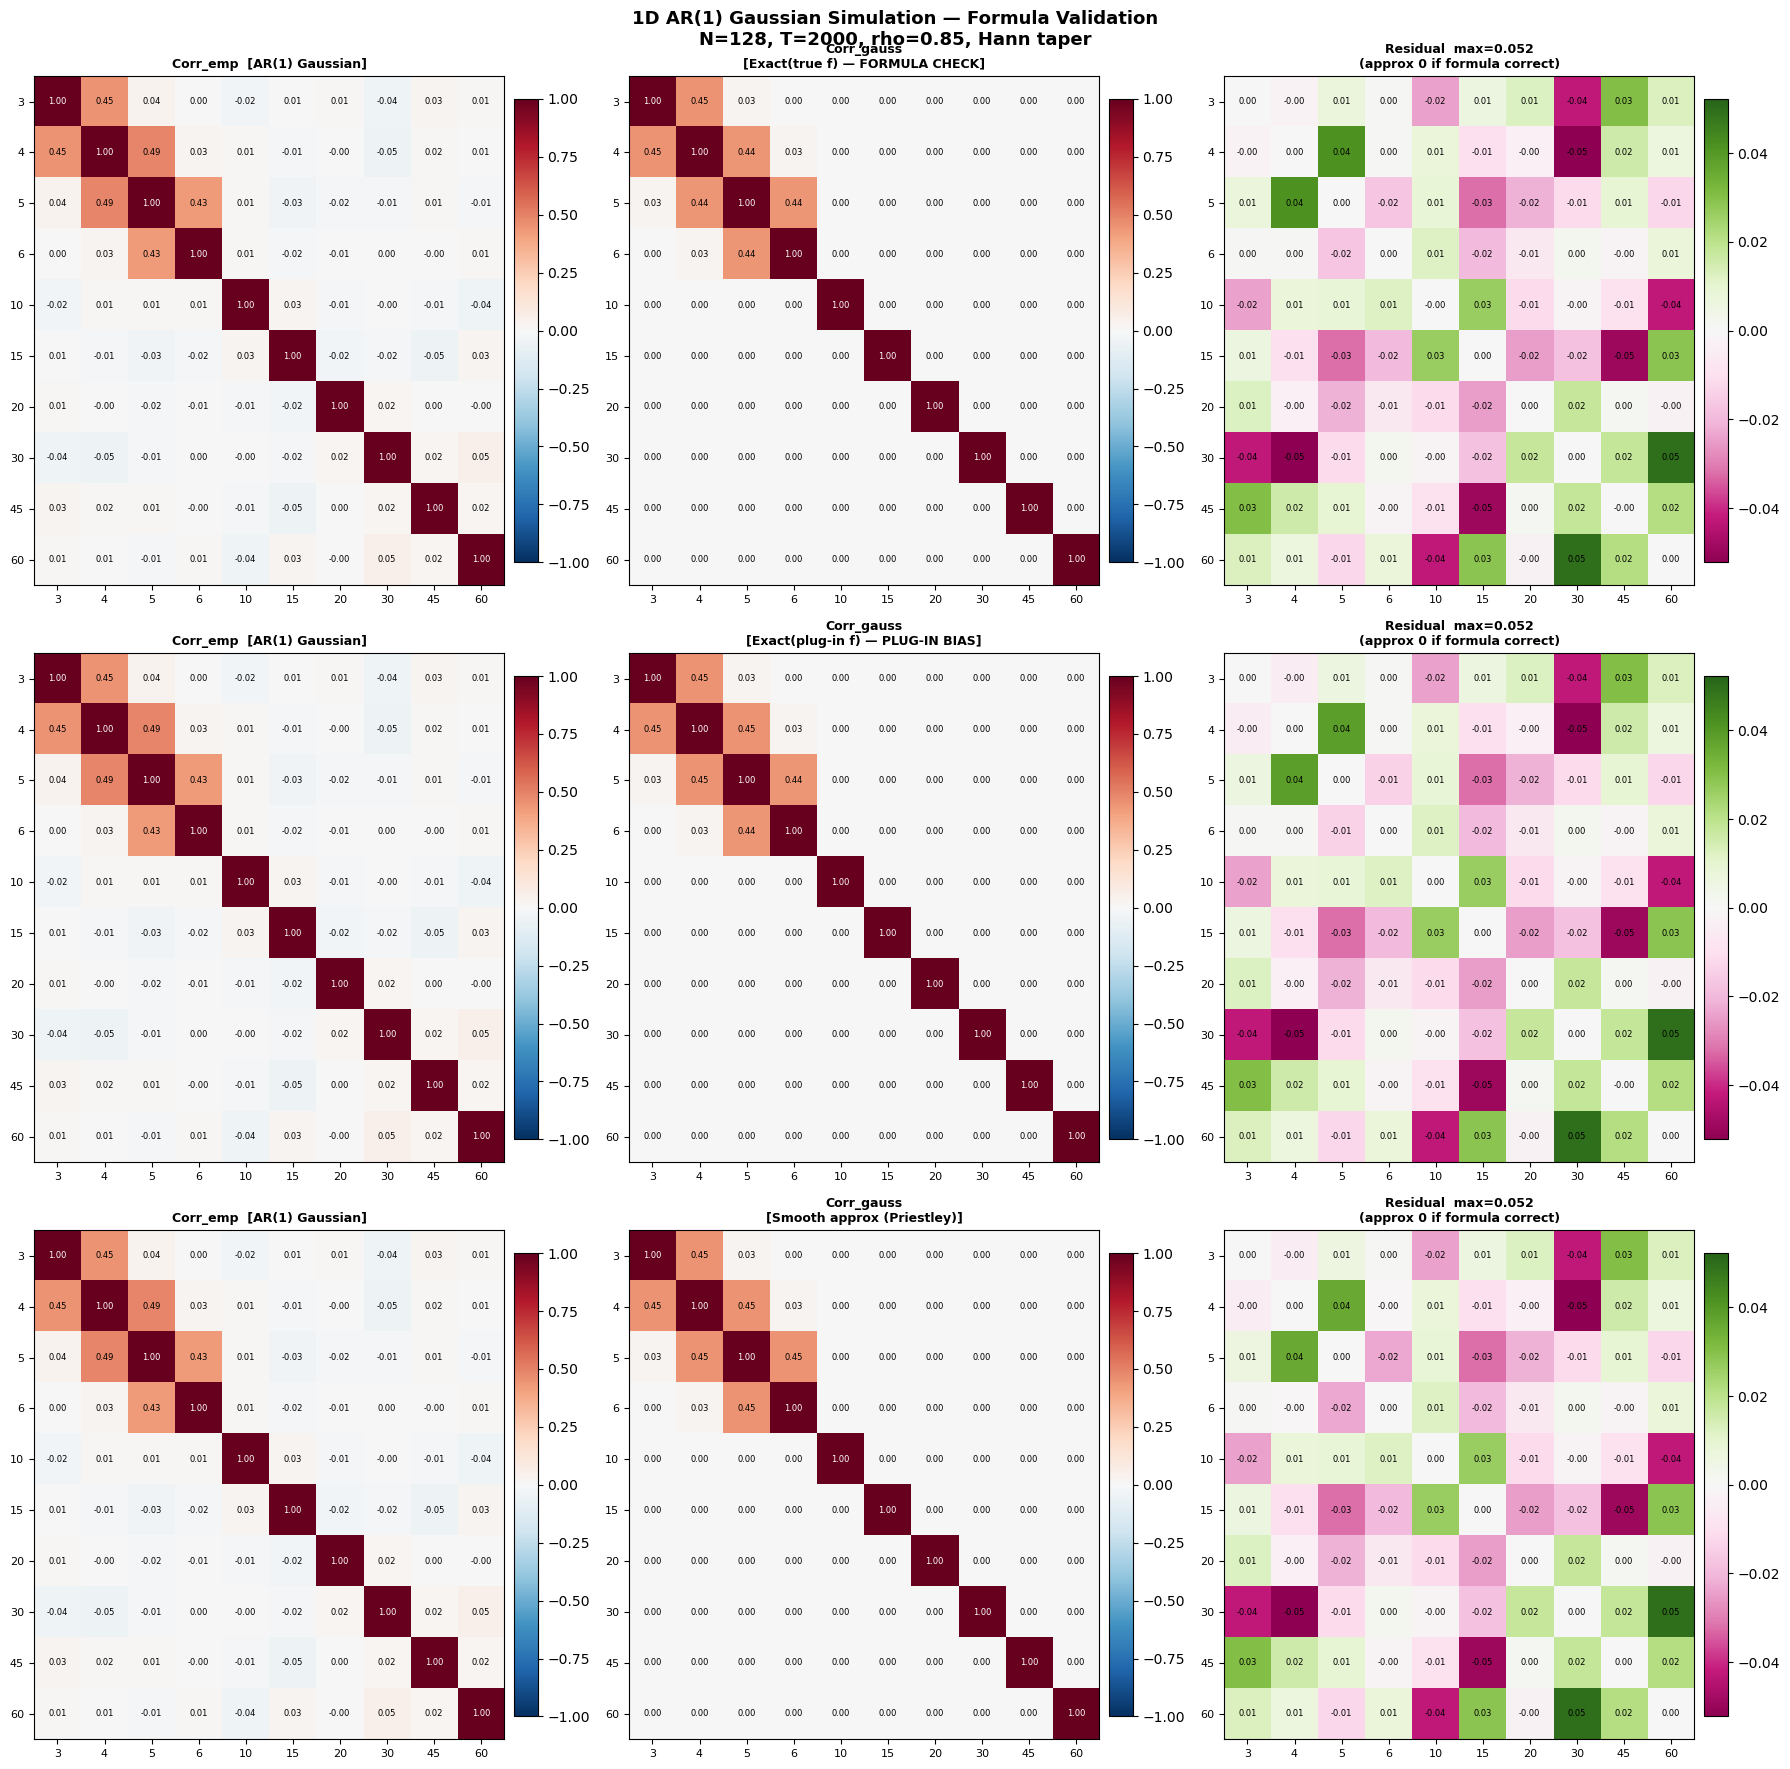

Saved /tmp/cov_sim_1d_formula.png


In [5]:
# ── Visualization ─────────────────────────────────────────────────────────────
def to_corr(C):
    std = np.sqrt(np.clip(np.diag(C), 1e-30, None))
    return C / np.outer(std, std)

Cemp  = to_corr(Cov_emp_tap)
Ctrue = to_corr(Cov_gauss_true)
Cplug = to_corr(Cov_gauss_plugin)
Csmth = to_corr(Cov_gauss_smooth)

tick_lbl = [str(j) for j in FREQS]

def draw_mat(ax, mat, cmap, vmin, vmax, title):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xticks(range(K)); ax.set_xticklabels(tick_lbl, fontsize=8)
    ax.set_yticks(range(K)); ax.set_yticklabels(tick_lbl, fontsize=8)
    for i in range(K):
        for l in range(K):
            ax.text(l, i, f'{mat[i,l]:.2f}', ha='center', va='center',
                    fontsize=6, color='white' if abs(mat[i,l])>0.5 else 'black')

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.suptitle(
    f'1D AR(1) Gaussian Simulation — Formula Validation\n'
    f'N={N}, T={T}, rho={RHO}, Hann taper',
    fontsize=13, fontweight='bold')

rows = [
    (Cemp, Ctrue, 'Exact(true f) — FORMULA CHECK',   Cemp-Ctrue),
    (Cemp, Cplug, 'Exact(plug-in f) — PLUG-IN BIAS', Cemp-Cplug),
    (Cemp, Csmth, 'Smooth approx (Priestley)',        Cemp-Csmth),
]
for r, (Ce, Cg, tag, res) in enumerate(rows):
    rlim = max(0.05, np.abs(res).max())
    draw_mat(axes[r,0], Ce,  'RdBu_r', -1, 1, f'Corr_emp  [AR(1) Gaussian]')
    draw_mat(axes[r,1], Cg,  'RdBu_r', -1, 1, f'Corr_gauss\n[{tag}]')
    draw_mat(axes[r,2], res, 'PiYG', -rlim, rlim,
             f'Residual  max={rlim:.3f}\n(approx 0 if formula correct)')

plt.tight_layout()
plt.savefig('/tmp/cov_sim_1d_formula.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved /tmp/cov_sim_1d_formula.png')

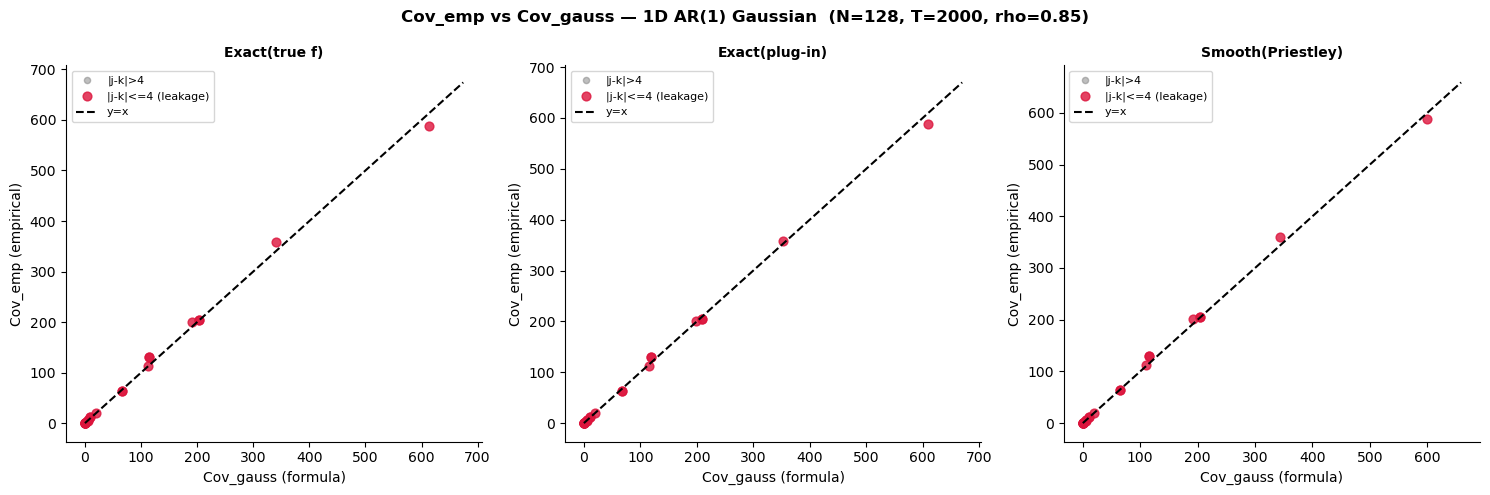

Saved /tmp/cov_sim_1d_scatter.png

RMSE(Cov_emp, Cov_gauss):
  Exact(true f)    overall=4.140084  diag=10.471341  off-diag=2.619456
  Exact(plug-in)   overall=3.010206  diag=7.263693  off-diag=2.050803
  Smooth           overall=3.041235  diag=6.659798  off-diag=2.312723


In [6]:
# ── Off-diagonal scatter: Cov_emp vs Cov_gauss(true f) ───────────────────────
# Key plot: if formula is correct, points should lie on y=x line
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Cov_emp vs Cov_gauss — 1D AR(1) Gaussian  (N={N}, T={T}, rho={RHO})',
             fontsize=12, fontweight='bold')

for ax, (Cg, label) in zip(axes, [
    (Cov_gauss_true,   'Exact(true f)'),
    (Cov_gauss_plugin, 'Exact(plug-in)'),
    (Cov_gauss_smooth, 'Smooth(Priestley)'),
]):
    xe = Cov_emp_tap.ravel()
    xg = Cg.ravel()
    near = np.array([abs(FREQS[i]-FREQS[l]) <= 4
                     for i in range(K) for l in range(K)])
    ax.scatter(xg[~near], xe[~near], s=20, alpha=0.5, color='gray',   label='|j-k|>4')
    ax.scatter(xg[ near], xe[ near], s=40, alpha=0.8, color='crimson', label='|j-k|<=4 (leakage)')
    lim = max(xg.max(), xe.max()) * 1.1
    ax.plot([0, lim], [0, lim], 'k--', lw=1.5, label='y=x')
    ax.set_xlabel('Cov_gauss (formula)', fontsize=10)
    ax.set_ylabel('Cov_emp (empirical)', fontsize=10)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/tmp/cov_sim_1d_scatter.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved /tmp/cov_sim_1d_scatter.png')

# Quantitative: RMSE of Cov_emp vs Cov_gauss
print(f'\nRMSE(Cov_emp, Cov_gauss):')
for Cg, label in [
    (Cov_gauss_true,   'Exact(true f)  '),
    (Cov_gauss_plugin, 'Exact(plug-in) '),
    (Cov_gauss_smooth, 'Smooth         '),
]:
    rmse = np.sqrt(np.mean((Cov_emp_tap - Cg)**2))
    rmse_diag = np.sqrt(np.mean((np.diag(Cov_emp_tap) - np.diag(Cg))**2))
    rmse_offdiag = np.sqrt(np.mean([(Cov_emp_tap[i,l]-Cg[i,l])**2
                                    for i in range(K) for l in range(K) if i!=l]))
    print(f'  {label}  overall={rmse:.6f}  diag={rmse_diag:.6f}  off-diag={rmse_offdiag:.6f}')